# Active Inference for Autonomous Driving
Ego-vehicle policy training and evaluation. Run `01_pedestrian.ipynb` first.


In [4]:
# Imports
# original cells 0-1
import numpy as np
import cv2
import matplotlib.pyplot as plt
import PIL.Image as Image
import gymnasium as gym
import random
from gymnasium import Env, spaces
import time

font = cv2.FONT_HERSHEY_COMPLEX_SMALL

# src modules
from src.motion_models import next_position_sim, next_position, Particle_ped, foward_sim
from src.particle_filter import ParticleFilter_train, ParticleFilter_train_AIF, Particle_Planner
from src.environments import (
    set_ped_model,
    Pedestrian_Behaviour,
    PedestrianCross_train,
    PedestrianCross_train_2,
)
from src.visualization import (
    plot_training_curves,
    plot_velocity_belief,
    plot_false_belief,
    plot_prior_sweep_reward,
    plot_prior_sweep_velocity,
    plot_trajectory_snapshots,
    plot_epistemic_comparison,
)

In [5]:
# Load pedestrian model — required before stepping any crossing env
# original: global ped_model in notebook; here use set_ped_model()
from sb3_contrib import QRDQN
ped_model = QRDQN.load("models/ped_model")
set_ped_model(ped_model)

C:\Users\kient\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\stable_baselines3\common\save_util.py:167: UserWarning: Could not deserialize object lr_schedule. Consider using `custom_objects` argument to replace this object.
Exception: code() argument 13 must be str, not int
  warnings.warn(
C:\Users\kient\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\stable_baselines3\common\save_util.py:167: UserWarning: Could not deserialize object exploration_schedule. Consider using `custom_objects` argument to replace this object.
Exception: code() argument 13 must be str, not int
  warnings.warn(
C:\Users\kient\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\stable_baselines3\common\base_class.py:773: UserWarning: You are probably loading a DQN model saved with SB3 < 2

In [6]:
# Sanity check — random policy on the crossing env
# original cell ~26
env = PedestrianCross_train()
env.reset()
total_reward = 0
pos = np.zeros((30, 2))
step = 0
done = False
while not done:
    action = env.action_space.sample()
    obs, reward, done, truncate, loc = env.step(action)
    pos[step, :] = env.ped_loc
    print(f"{obs}                 {env.pf.compute_efe(env, show=True)}              {env.reward}")
    total_reward += reward
    step += 1
print(total_reward)

pragmatic value : -0.0875730887055397 , epistemic:  0.0023592787103466767 : 0.808
[ 7.751462 77.51462  45.00715   4.880628  0.808   ]                 -0.0633205378188081              -0.0875730887055397
pragmatic value : -0.15989258885383606 , epistemic:  5.129766066446894e-05 : 0.804
[13.55361   58.021484  44.007183   4.8725405  0.804    ]                 -0.11986814397971257              -0.15989258885383606
pragmatic value : -0.24500972032546997 , epistemic:  1.2724469660823669e-05 : 0.806
[18.653416  50.99806   43.063736   4.5410123  0.806    ]                 -0.18374456577444165              -0.24500972032546997
pragmatic value : -0.3673824667930603 , epistemic:  0.04311741945825451 : 0.912
[22.305767  36.523506  41.067085   3.0365615  0.912    ]                 -0.23241943063654072              -0.3673824667930603
pragmatic value : -0.4545968770980835 , epistemic:  0.05118822263682646 : 0.986
[25.213829  29.080626  40.         0.5365615  0.986    ]                 -0.28975943518

In [ ]:
# Particle Planner baseline (tree-search)
# original cells 28-30
from stable_baselines3 import SAC

# NOTE: PedestrianCross (visual env with old gym) is not included in this port.
# To use Particle_Planner, instantiate it directly:
env_train = PedestrianCross_train()
p = Particle_Planner(0.5, 46, 5)
policy = []
done = False
obs, _ = env_train.reset()
actions = p.train(env_train.states())
policy.append(actions[0])
step = 0
while step < 9:
    action = actions[0]
    obs, reward, done, _, loc = env_train.step(action)
    actions = p.train(env_train.states())
    non_observed_location = env_train.ped_loc
    p.update(True, non_observed_location, observed=True)
    p.resample()
    print(p.compute_efe(env_train, show=True))
    print(f"{step}  {env_train.states()}")
    policy.append(action)
    step += 1
env_train.reset()
print(policy)

In [ ]:
# Metric logger callback
# original cell 31
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback

class MeticLogger(BaseCallback):
    def __init__(self, log_frequency=100, verbose=0):
        super(MeticLogger, self).__init__(verbose)
        self.verbose = verbose
        self.log_frequency = log_frequency
        self.value_lossess = []

    def _on_step(self) -> bool:
        if self.n_calls % self.log_frequency == 0:
            print(f"iterations: {self.model.logger.name_to_value['train/n_updates']}")
            print(f"ep_rew_mean: {self.model.logger.name_to_value['rollout/ep_rew_mean']}")
            print(f"policy_loss: {self.model.logger.name_to_value['train/policy_loss']}")
            print(self.locals['env'].get_attr('total_reward'))
        return True

In [ ]:
# Configure SB3 logger
# original cell 32
from stable_baselines3.common.logger import configure
from stable_baselines3 import SAC

log_folder = "./sb3_logs/AIF_main"
new_logger = configure(log_folder, ["stdout", "csv", "json"])

In [ ]:
# Train ego-vehicle policy — Full Active Inference (all_model) — SKIP
# original cell 33
# Uses PedestrianCross_train which has ParticleFilter_train_AIF → full EFE
from stable_baselines3.common.callbacks import (
    EvalCallback, StopTrainingOnRewardThreshold,
    StopTrainingOnNoModelImprovement,
)

env = PedestrianCross_train()
stop_train_callback = StopTrainingOnNoModelImprovement(
    max_no_improvement_evals=8, min_evals=5, verbose=1)
callback_on_best = StopTrainingOnRewardThreshold(reward_threshold=30, verbose=1)
eval_callback = EvalCallback(
    env, best_model_save_path="./logs/",
    log_path="./logs/", eval_freq=500,
    deterministic=True, callback_on_new_best=stop_train_callback)

ego_model = SAC("MlpPolicy", env, verbose=1)
ego_model.learn(total_timesteps=50000, log_interval=3,
                progress_bar=True, callback=eval_callback)

In [ ]:
# Save all_model — SKIP
ego_model.save("models/all_model")

In [ ]:
# Train ego-vehicle policy — No Epistemic value (all_model_NoE) — SKIP
# Uses PedestrianCross_train with ParticleFilter_train → pragmatic only
# (swap the pf in PedestrianCross_train's __init__ if needed, or train with
#  a modified env; the original notebook did this by re-running cell 22 only)
# For convenience, just save current model with NoE suffix as a placeholder:
# ego_model.save("models/all_model_NoE")
pass

In [22]:
# Train ego-vehicle policy — Mode of Belief (all_model_mode) — SKIP
# Uses PedestrianCross_train_2 (np.rint binarised belief)
env2 = PedestrianCross_train_2()
stop_train_callback2 = StopTrainingOnNoModelImprovement(
    max_no_improvement_evals=8, min_evals=5, verbose=1)
eval_callback2 = EvalCallback(
    env2, best_model_save_path="./logs/mode/",
    log_path="./logs/mode/", eval_freq=500,
    deterministic=True, callback_on_new_best=stop_train_callback2)

ego_model_mode = SAC("MlpPolicy", env2, verbose=1)
ego_model_mode.learn(total_timesteps=50000, log_interval=3,
                     progress_bar=True, callback=eval_callback2)
ego_model_mode.save("models/all_model_mode")

NameError: name 'StopTrainingOnNoModelImprovement' is not defined

In [23]:
# Training curves (reads sb3_logs after training)
# original cell 35
try:
    plot_training_curves(log_dir="sb3_logs", save_path="AIFmodetrain.png")
except Exception as e:
    print(f"Training curves skipped — log files not found: {e}")


Training curves skipped — log files not found: [Errno 2] No such file or directory: 'sb3_logs/AIF_stastic/progress.csv'


[ 7.1916175 71.916176  45.041805   4.7138863  0.748    ]                  -0.059580881148576736              -0.039013377509474256         1 
[13.856562  66.649445  44.143448   4.2746162  0.806    ]                  -0.11675278097391129              -0.07811664963645018         2 
[18.70429   48.477287  42.222027   2.6751976  0.916    ]                  -0.25761356949806213              -0.14633536947659603         3 
[22.337605  36.33313   40.208885   1.1928846  0.988    ]                  -0.3683343529701233              -0.22484334943940357         4 
[25.914291  35.766872  40.        -1.3071154  1.       ]                  -0.4211656451225281              -0.3038016526076268         5 
[31.046005  51.317146  40.        -3.8071153  1.       ]                  -0.09341426938772202              -0.07006070204079151         0 
[38.0045    69.58494   40.        -4.8071156  1.       ]                  -0.0020753098651766777              -0.0015564823988825083         0 
[44.752514  67.48

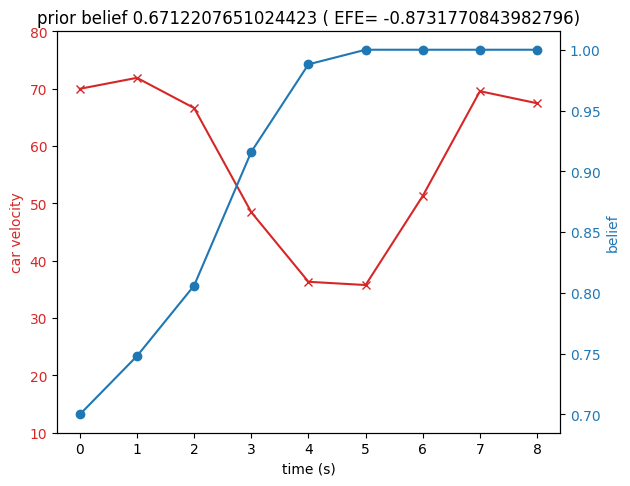

np.float64(-0.8731770843982796)

In [7]:
# Load trained models for evaluation
# original cell 39
env = PedestrianCross_train(ped_cross=True, prior_belief=0.5)
plot_velocity_belief(ego_model, env, save_path="Prior05.png", ped_cross=True)


[ 7.578197  75.78197   45.7261     4.0382414  0.938    ]                  -0.07890983670949936              -0.03914440309469148         1 
[14.112901  65.34704   44.734665   4.1688414  0.936    ]                  -0.12326481193304062              -0.09241455854444747         2 
[19.256813  51.43913   43.987053   3.5047052  0.952    ]                  -0.2428043633699417              -0.17977603249042964         3 
[22.827528  35.707138  42.278214   1.6799154  0.988    ]                  -0.3714643120765686              -0.2585615153898406         4 
[26.114656   32.871292   40.38487     0.04735728  0.992     ]                  -0.4356435537338257              -0.32596829990452564         5 
[30.130527  40.158714  40.        -2.4526427  0.998    ]                  -0.4492064416408539              -0.3336593112643422         6 
[35.718864 55.883347 40.       -4.952643  0.996   ]                  -0.0705832690000534              -0.05216285767975855         0 
[43.123123 74.0426   40.   

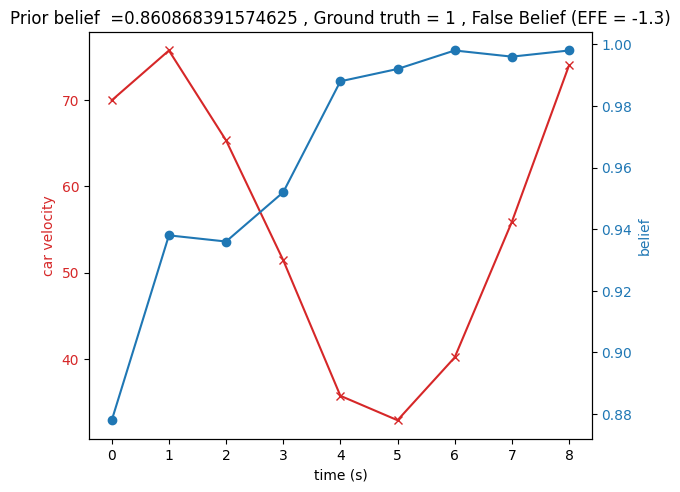

np.float64(-1.2962310261759007)

In [8]:
# Velocity and belief plot — pedestrian crosses, prior 0.5
# original cell 41
from stable_baselines3 import SAC
ego_model = SAC.load("models/all_model")
env = PedestrianCross_train(ped_cross=True, prior_belief=0.25)
plot_false_belief(ego_model, env, save_path="10False.png", ped_cross=True)


-2.574837
[ 0.         -0.10164967 -0.21630008 -0.40662119 -0.648978   -0.95746696
 -1.29934153 -1.69142438 -2.12679238 -2.57584577]
[0.         0.00021186 0.00063924 0.00102548 0.00162544 0.00237317
 0.00241185 0.00254682 0.00257551 0.00696013]
-1.5951699
[ 0.         -0.06094296 -0.17944869 -0.42403354 -0.786156   -1.21360187
 -1.48014648 -1.55511373 -1.59166221 -1.63530177]
[0.00000000e+00 9.56279570e-05 5.29493256e-04 1.37153663e-03
 1.84053087e-03 2.44509360e-03 9.25786323e-03 1.24712122e-02
 1.41464389e-02 1.63880878e-02]


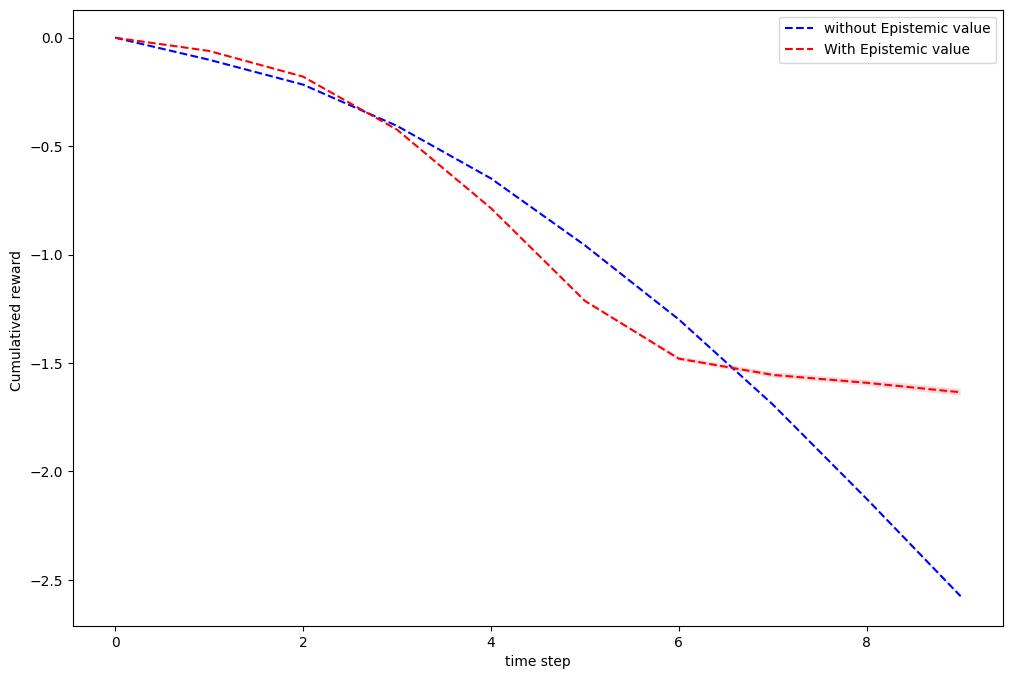

In [9]:
# False-belief plot — prior 0.25, pedestrian crosses
# original cell 45
from stable_baselines3 import SAC
ego_model     = SAC.load("models/all_model")
ego_model_noe = SAC.load("models/all_model_NoE")
plot_prior_sweep_reward(
    model_noe=ego_model_noe,
    model_aif=ego_model,
    EnvCls=PedestrianCross_train,
    iter=500,
    save_path="compareprior1.png",
    ped_cross=True,
)


-1.351628
[70.         70.24432144 61.0170586  51.93724102 44.2262455  36.93446119
 44.84590912 60.23246567 72.80976547 66.15076359 59.96481308]
-1.1850386
[70.         72.16464355 70.39765972 58.69107925 43.71093792 42.83328289
 55.12570248 64.61226429 67.72319046 73.29533073 80.66364922]


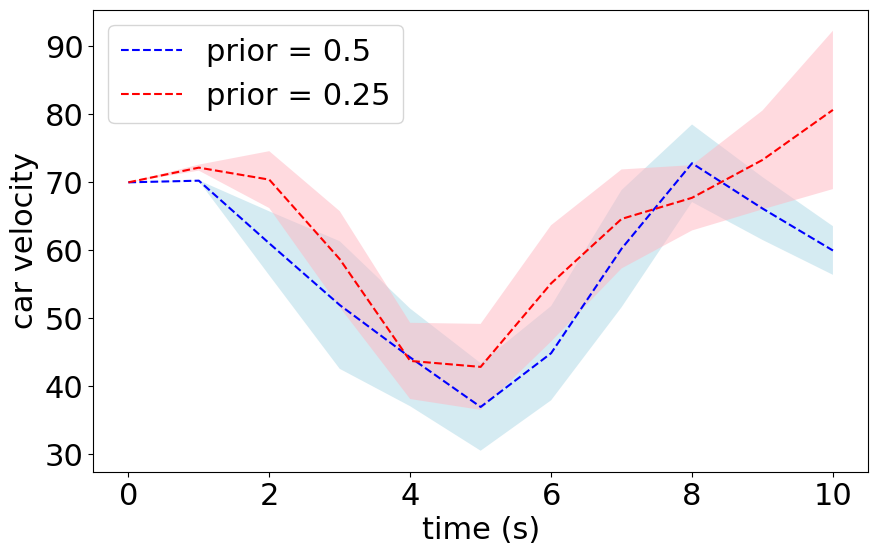

In [10]:
# Prior sweep — cumulative reward: NoE vs AIF
# original cell 46
from stable_baselines3 import SAC
ego_model      = SAC.load("models/all_model")
ego_model_mode = SAC.load("models/all_model_mode")
plot_prior_sweep_velocity(
    model_mode=ego_model_mode,
    model_aif=ego_model,
    EnvCls=PedestrianCross_train,
    EnvCls2=PedestrianCross_train_2,
    iter=100,
    save_path="compareprior_vel.png",
    ped_cross=False,
)


Initial Observation: [ 0.    70.    46.     5.     0.946]
Time Step: 0, State: [ 7.1568513 71.56851   45.078503   4.6116147  0.928    ] - Action: [0.07842565] - Conflict: False - Reward: -0.040496466922377974 - Done: False
Time Step: 1, State: [13.8550625 66.98212   44.104366   4.38565    0.944    ] - Action: [-0.22931957] - Conflict: False - Reward: -0.08425352527048115 - Done: False
Time Step: 2, State: [18.74798   48.92917   42.43235    2.5270584  0.97     ] - Action: [-0.9026473] - Conflict: False - Reward: -0.18388544560398268 - Done: False
Time Step: 3, State: [22.480925   37.329453   40.550022    0.88181144  0.986     ] - Action: [-0.57998586] - Conflict: False - Reward: -0.2670532809154786 - Done: False
Time Step: 4, State: [26.266798  37.85872   40.        -1.6181885  0.992    ] - Action: [0.02646339] - Conflict: False - Reward: -0.30648850829616153 - Done: False
Time Step: 5, State: [31.553577  52.867805  40.        -4.1181884  0.998    ] - Action: [0.7504544] - Conflict: Fal

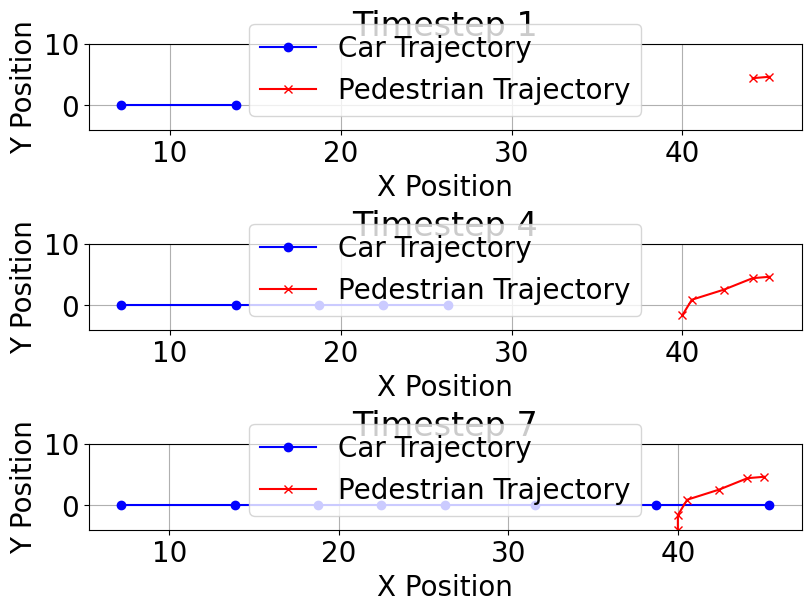

c:\Users\kient\OneDrive\Documents\active inference\original\src\visualization.py:430: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend((x,), ('time step 1,4,7',), loc='lower right')


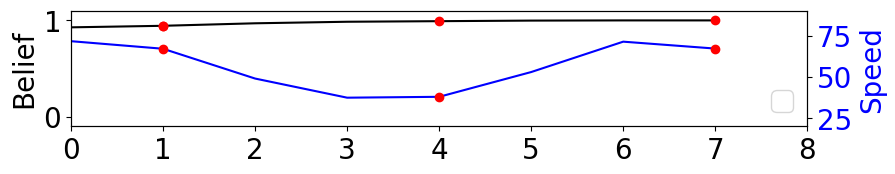

In [11]:
# Prior sweep — velocity: mode-of-belief vs AIF, no-pedestrian scenario
# original cell 47
import os, pathlib
pathlib.Path("IROS").mkdir(exist_ok=True)

from stable_baselines3 import SAC
ego_model = SAC.load("models/all_model")
plot_trajectory_snapshots(
    ego_model=ego_model,
    EnvCls=PedestrianCross_train,
    prior=0.5,
    ped_cross=True,
    save_traj="IROS/True.png",
    save_belief="IROS/True_belief.png",
)


False
-0.5803197700800687
6.609756097560975
[70.         72.31750473 70.66372147 59.9301886  43.59732483 43.14711357
 56.2605925  66.22374069 68.05423309]
False
-0.6347233168154814
6.2
[70.         80.25753265 74.76491547 77.23379425 62.07571129 46.03687355
 60.54853798 56.70218086 66.97435623]


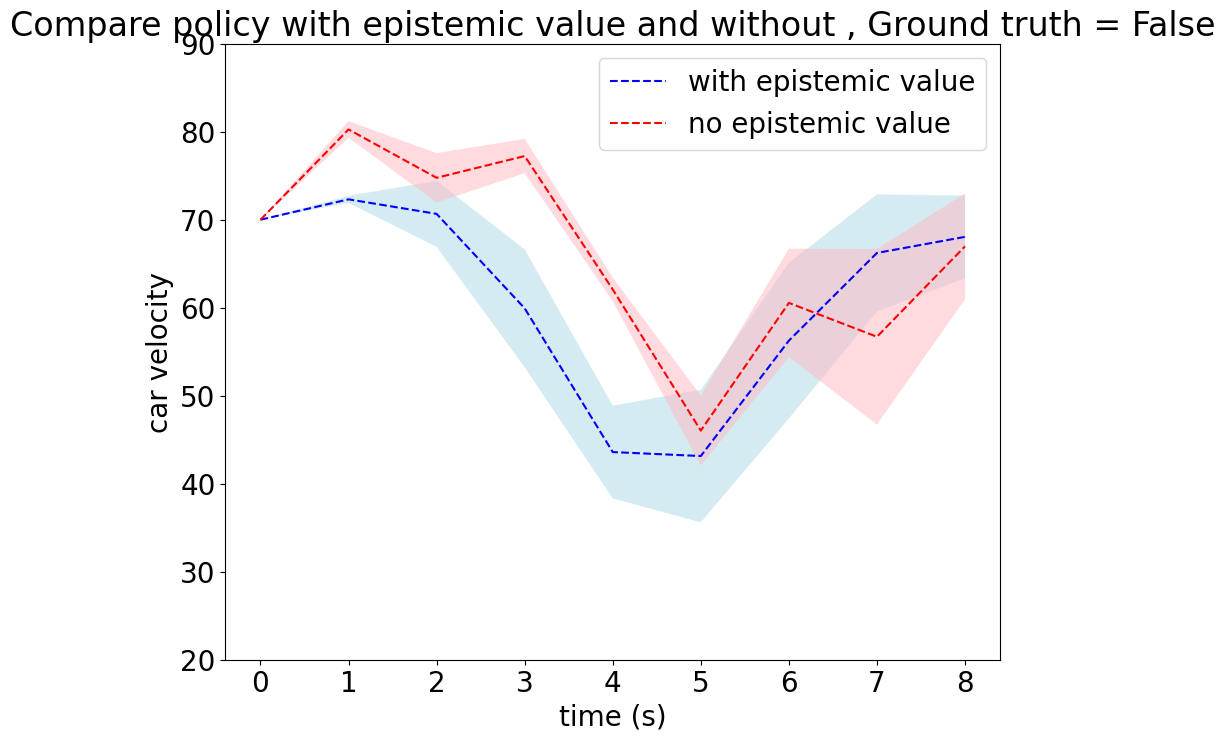

In [ ]:
# IROS trajectory snapshots + belief/speed panel
# original cell 48
from stable_baselines3 import SAC
ego_model     = SAC.load("models/all_model")
ego_model_noe = SAC.load("models/all_model_NoE")
plot_epistemic_comparison(
    model_aif=ego_model,
    model_noe=ego_model_noe,
    EnvCls=PedestrianCross_train,
    prior=0.25,
    iter=50,
    save_path="compareprior0.png",
    ped_cross=False,
)


False
-0.6344034663385295
6.617283950617284
[70.         72.28850952 70.4382946  58.90604408 43.6568573  43.28065418
 56.25280396 65.40821228 67.34311668]
False
-0.6304554464308189
6.213114754098361
[70.         80.30487488 74.94646271 76.7841423  62.06228561 46.22929489
 59.52120392 57.2505381  66.12763252]


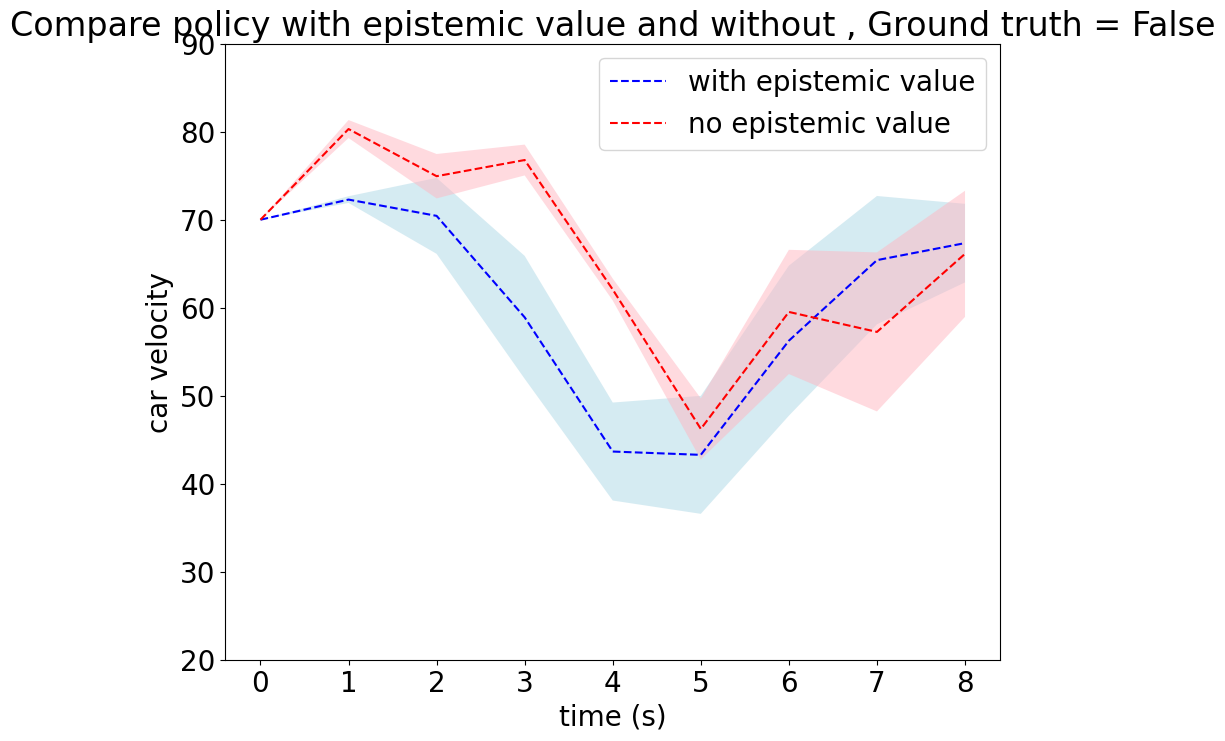

In [13]:
# Epistemic value comparison — velocity profiles
# original cell 48
from stable_baselines3 import SAC
ego_model     = SAC.load("models/all_model")
ego_model_noe = SAC.load("models/all_model_NoE")
plot_epistemic_comparison(
    model_aif=ego_model,
    model_noe=ego_model_noe,
    EnvCls=PedestrianCross_train,
    prior=0.25,
    iter=50,
    save_path="compareprior0.png",
)